# Phishing Email Detection Report

Alumnos:
- Carlos Berdaguer - a2605
- Lucas Campi - a2609

## Introducción

En nuestra búsqueda de datasets, nos encontramos con este que es bastante actual. Durante cursadas previas, hemos visto en algunas ocasiones que se mencionaba al caso de "detección de SPAM" como un ejemplo bastante común en los problemas de modelos de clasificación. Nos pareció una buena oportunidad poder indagar un poco más sobre esta clásica temática y ponerlo en práctica.

---

#### Descripción del dataset


| Variable      | Descripción                                                                      |
| ------------- | ---------------------------------------------------------------------------------- |
| `email_id`    | Identificador único para cada fila                                  |
| `sender_email` | Emisor desde el cual se envío el mensaje a detectar                                               |
| `subject`         | Asunto o tópico del correo                                             |
| `has_link`         | 1 = Contiene links, 0 = no contiene                                                   |
| `has_attachment`       | 1 = Tiene documentos adjuntos, 0 = no contiene                                             |
| `urgency_score`       | Nivel de urgencia                                            |
| `spelling_errors`        | Cantidad de errores ortográficos en el correo                                                     |
| `email_length_words`    | Longitud del correo en cantidad de palabras     |
| `is_pishing`       | 1 = Es fishing, 0 = no lo es |

---

In [153]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [154]:
# Carga del dataset
ph_df = pd.read_csv("./dataset/phishing_email_detection_2026_dataset.csv")
ph_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   email_id            1500 non-null   int64
 1   sender_email        1500 non-null   str  
 2   subject             1500 non-null   str  
 3   has_link            1500 non-null   int64
 4   has_attachment      1500 non-null   int64
 5   urgency_score       1500 non-null   int64
 6   spelling_errors     1500 non-null   int64
 7   email_length_words  1500 non-null   int64
 8   is_phishing         1500 non-null   int64
dtypes: int64(7), str(2)
memory usage: 169.9 KB


Podemos observar que el dataset está completo. El mismo presenta las 9 variables vistas anteriormente, donde se identifican como:
- email_id: numérica discreta
- sender_email: categórica nominal
- subject: categórica nominal
- has_link: numérica discreta pero que podría ser una variable binaria (categórica nominal).
- has_attachment: numérica discreta pero que podría ser una variable binaria (categórica nominal).
- urgency_score: numérica discreta
- spelling_errors: numérica discreta
- email_length_words: numérica discreta
- is_phishing: numérica discreta pero que podría ser una variable binaria (categórica nominal).

De las variables, claramente *is_phishing* es nuestra target.

In [155]:
ph_df.describe()

,email_id,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,0.629333,0.512667,5.722667,3.708000,132.559333,0.493333
std,433.157015,0.483144,0.500006,3.002182,3.209819,79.315970,0.500122
min,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.000000
25%,375.750000,0.000000,0.000000,3.000000,1.000000,72.000000,0.000000
50%,750.500000,1.000000,1.000000,5.000000,2.000000,108.000000,0.000000
75%,1125.250000,1.000000,1.000000,8.000000,6.000000,193.000000,1.000000
max,1500.000000,1.000000,1.000000,10.000000,10.000000,300.000000,1.000000


Para tener un paneo general, detectamos las siguientes características del dataset:
- Más de la mitad de correos (63%) contenían links.
- La mitad (51%) tenía algún acrchivo adjuntos.
- De un promedio de 132 palabras, se detectan 3 con errores ortográficos, por lo que parecería que, por lo general, los correos están bien escdritos.
- La mitad (49%) fueron phishing.

Es un dataset equilibrado en cuanto a casos positivos y casos negativos, pero no tiene muchas observaciones (solo 1500), por lo que tendremos que ser precavidos en el entrenamiento del modelo a seleccionar.

---
* Tratamiento por datos faltantes, técnicas de imputación
* Eliminación de datos repetidos.
* Discretización de variables.
* Escalamiento de variables.
* Tratamiento de outliers.
* Reducción de dimensionalidad.
* Filtrado de variables.

## 1. Datos repetidos

Observemos si tenemos un mismo sender en varios correos.

In [156]:
ph_df["sender_email"].nunique()

1499

Observamos que hay 1499 elementos distintos, por lo que nos da una pequeña de pista de que los correos de phishing no suelen salir de un mismo emisor, sino que este correo parece variar en cada ataque.

Veamos ahora de qué dominio suelen salir los correos

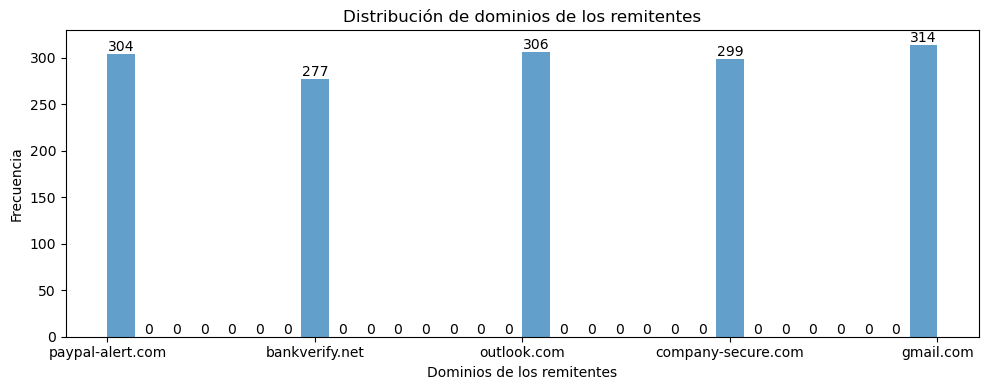

In [201]:
domains = ph_df["sender_email"].apply(lambda x: x.split("@")[-1])
fig, ax = plt.subplots(figsize=(10, 4))

count, bins, bars = ax.hist(domains, bins=30, alpha=0.7)
ax.set_xlabel('Dominios de los remitentes')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de dominios de los remitentes')
ax.bar_label(bars)

plt.tight_layout()
plt.show()

Podemos observar que la cantidad de emisores de este dataset es bastante equitativa, con presencia de dos medios oficiales como outlook y gmail. Vamos a observar qué cantidad de phishing se reportaron según cada emisor.

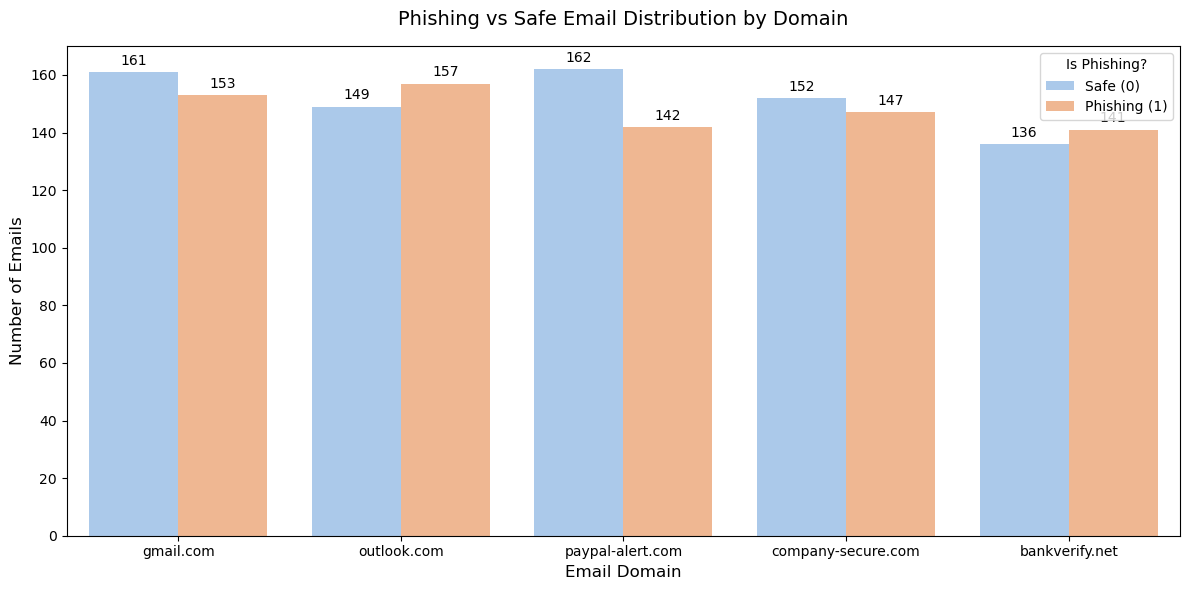

In [206]:
emails_with_phishing = ph_df[["sender_email", "is_phishing"]]
emails_with_phishing["domain"] = emails_with_phishing["sender_email"].apply(lambda x: x.split("@")[-1])
emails_with_phishing.drop("sender_email", axis=1, inplace=True)
emails_with_phishing.groupby("domain").count()
counts = emails_with_phishing.groupby("domain")["is_phishing"].value_counts()

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=emails_with_phishing,
    x="domain",
    hue="is_phishing",
    palette="pastel",
    order=emails_with_phishing["domain"].value_counts().index
)

# Clean up titles and labels
plt.title("Phishing vs Safe Email Distribution by Domain", fontsize=14, pad=15)
plt.xlabel("Email Domain", fontsize=12)
plt.ylabel("Number of Emails", fontsize=12)
plt.legend(title="Is Phishing?", labels=["Safe (0)", "Phishing (1)"])

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Se observa que el phishing puede provenir de cualquier dominio, por lo que el hecho de que vednga de un dominio oficial no garantiza que el correo no sea phishing. Es decir, nos quita la sospecha de que el phishing solo proviene de dominios "extraños".

Veamos, por último, si existe algún patrón relacionado con el uso de links o documentos adjuntos en el correo.

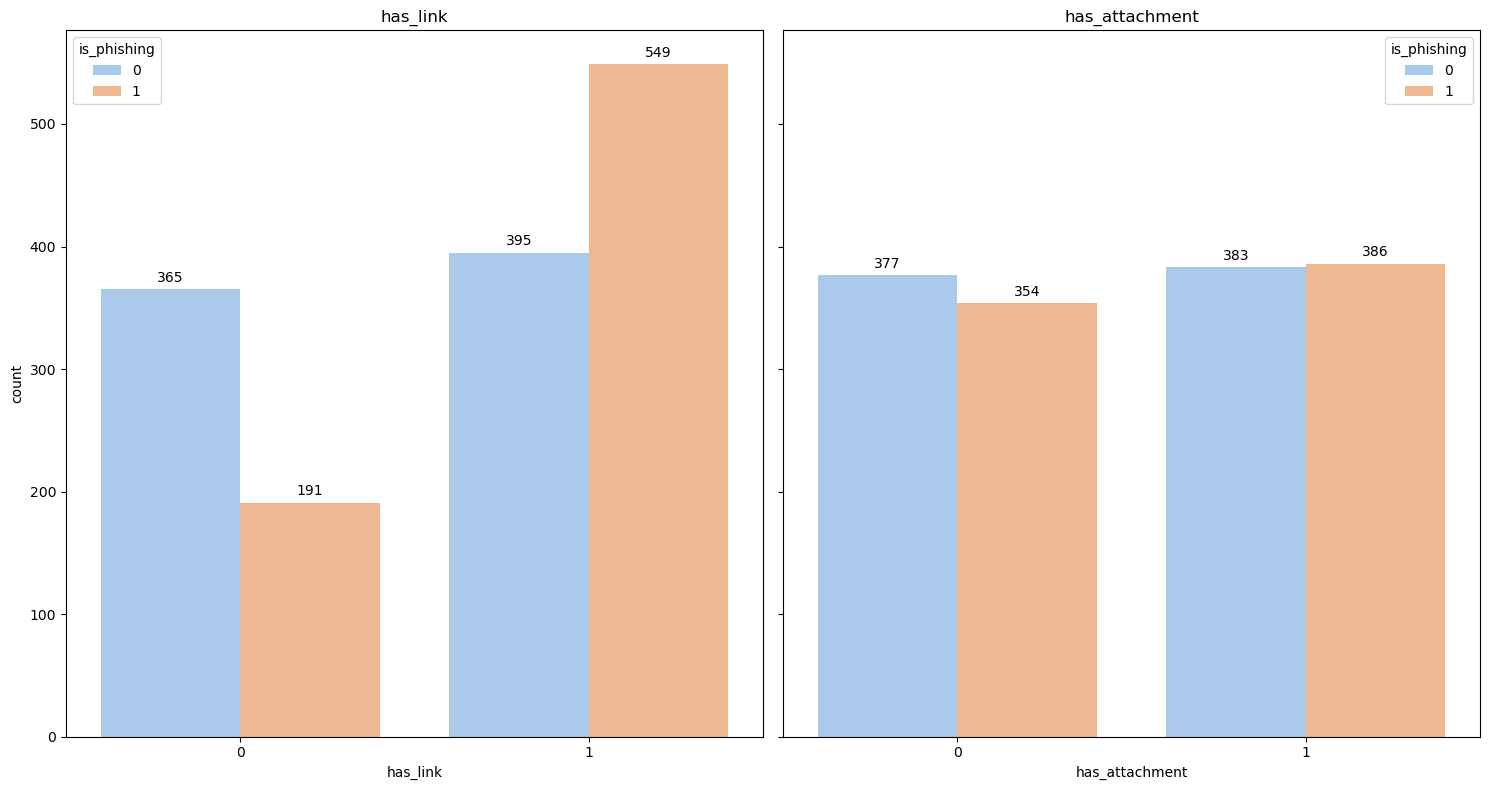

In [222]:
columns = ["has_link", "has_attachment"]

fig, axes = plt.subplots(1, len(["has_link", "has_attachment"]), figsize=(15, 8), sharey=True)

for ax, col in zip(axes, columns):
    sns.countplot(
        data=ph_df,
        x=col,
        hue="is_phishing",
        palette="pastel",
        ax=ax
    )

    ax.set_title(col)

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10)

plt.tight_layout()
plt.show()